# Model Analysis

## Import Library

In [1]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

2026-02-27 23:07:23.752546: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-27 23:07:23.791442: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-27 23:07:25.041468: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df_train = pd.read_csv('../split/train.csv')
df_train.head()

,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps,Target
0,88.0,82.0,34.0,-580.0,0.800684,0.000000,0
1,26.0,65.0,33.8,-208.0,1.061196,0.000000,1
2,37.0,73.0,32.4,-238.0,3.132320,120.947110,1
3,63.0,80.0,34.9,-674.0,2.962450,85.581960,0
4,38.0,72.0,34.6,-172.0,1.024259,2.122253,1


In [3]:
X_test = df_train.drop("Target", axis=1)
y_test = df_train["Target"]

## Mode Evaluation

In [4]:
def evaluate_model(model):
    class_name = ['High Load', 'Low Load']

    y_prob = model.predict(X_test).ravel()
    y_predict = (y_prob >= 0.5).astype(int)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_predict, target_names=class_name))

    cm = confusion_matrix(y_test, y_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix - ANN (Threshold = 0.5)")
    plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Classification Report

              precision    recall  f1-score   support

   High Load       0.99      0.98      0.98       292
    Low Load       0.98      0.99      0.99       333

    accuracy                           0.99       625
   macro avg       0.99      0.99      0.99       625
weighted avg       0.99      0.99      0.99       625



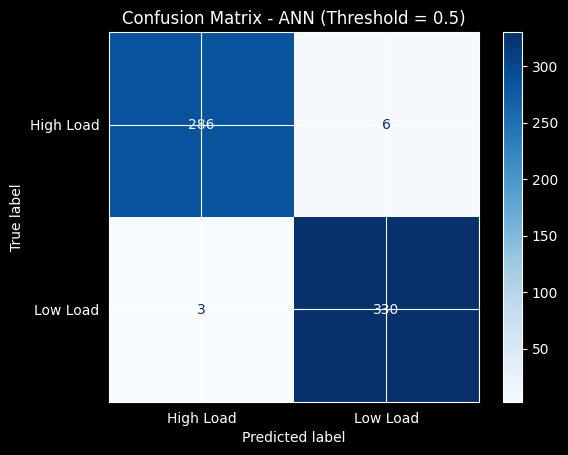

In [6]:
model = tf.keras.models.load_model('../model/model.keras')
evaluate_model(model)